# Feedback Simulator
Don't forget to
`sshfs -o allow_other,defer_permissions alexandresayal@192.168.0.68:/ /Users/alexandresayal/sftp -ovolname=sftp`

In [162]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [163]:
# Settings
data_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep'
nilearn_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/nilearn_glm'
output_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/feedbackSimulator'

In [164]:
subject_label = 'sub-05'
tr = 1 # in seconds
hrf_delay = 4 # in seconds

# get paths
task_label = f'task-AA_acq-{round(tr*1000):04}_run-1'
fmri_img = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz')
mask_img = os.path.join(nilearn_dir,'group','mask_hMT.nii.gz')
confounds_file = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_desc-confounds_timeseries.tsv')
events_file = os.path.join(data_dir, subject_label, 'func', f'{subject_label}_{task_label}_events.tsv')


In [165]:
# load confounds (all columns that start with 'cosine', 'csf', 'white_matter')
# and remove NaNs
confounds = pd.read_csv(confounds_file, sep='\t')
confounds = confounds.filter(regex='^(csf|white_matter|trans|rot).*')
confounds.fillna(0, inplace=True)

confounds.columns

Index(['csf', 'csf_derivative1', 'csf_power2', 'csf_derivative1_power2',
       'white_matter', 'white_matter_derivative1',
       'white_matter_derivative1_power2', 'white_matter_power2', 'csf_wm',
       'trans_x', 'trans_x_derivative1', 'trans_x_derivative1_power2',
       'trans_x_power2', 'trans_y', 'trans_y_derivative1',
       'trans_y_derivative1_power2', 'trans_y_power2', 'trans_z',
       'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
       'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2',
       'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_power2',
       'rot_y_derivative1_power2', 'rot_z', 'rot_z_derivative1',
       'rot_z_derivative1_power2', 'rot_z_power2'],
      dtype='object')

In [166]:
# Load events file
events = pd.read_csv(events_file, sep='\t')
events

,onset,duration,trial_type
0,0,15,Discard
1,15,30,Static
2,45,120,Ambiguous
3,165,15,MAE
4,180,30,Static
5,210,120,Ambiguous
6,330,15,MAE
7,345,30,Static
8,375,15,Discard


In [167]:
# Fetch the points of 'Static' events (to normalize the time_series)
static_events = events[events['trial_type']=='Static']

# Get the time points of the static events - these start at the onset and last for duration
static_events_onsets = static_events['onset'].values
static_events_durations = static_events['duration'].values

# create vector with all the time points of the static events
static_events_indexes = np.array([])
for i in range(len(static_events_onsets)):
    static_events_indexes = np.append(static_events_indexes, np.arange(static_events_onsets[i]/tr, static_events_onsets[i]/tr+static_events_durations[i]/tr))

static_events_indexes = ( static_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
static_events_indexes


array([ 18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
        31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
        44,  45,  46,  47, 183, 184, 185, 186, 187, 188, 189, 190, 191,
       192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204,
       205, 206, 207, 208, 209, 210, 211, 212, 348, 349, 350, 351, 352,
       353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365,
       366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377])

In [168]:
# get the time points of the ambiguous blocks
ambiguous_events = events[events['trial_type']=='Ambiguous']
ambiguous_events_onsets = ambiguous_events['onset'].values
ambiguous_events_durations = ambiguous_events['duration'].values

# create matrix with all the time points of the ambiguous blocks, one per column
ambiguous_events_indexes = np.array([])

# convert times to indexes and add hemodynamic delay
for i in range(len(ambiguous_events_onsets)):
    ambiguous_events_indexes = np.append(ambiguous_events_indexes,
                                         np.arange(ambiguous_events_onsets[i]/tr, ambiguous_events_onsets[i]/tr+ambiguous_events_durations[i]/tr))

ambiguous_events_indexes = ( ambiguous_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
ambiguous_events_indexes

array([ 48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,
        87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99,
       100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222,
       223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235,
       236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248,
       249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261,
       262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 27

In [169]:
# Load cluster table (this does not work for all subjects)
# to do: manually verify cluster coordinates for every subject
cluster_table = pd.read_csv(
    os.path.join(nilearn_dir,f'{subject_label}_task-loc_contrast-movingplaidMinusStaticplaid_c-bonferroni_p-0.05_clusterk-50_cluster-table.tsv'),
    sep='\t')

cluster_table


,Unnamed: 0,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,0,1,-24.5,-96.5,25.5,14.948313,49840.0
1,1,1a,47.5,-80.5,17.5,11.235698,NaN
2,2,1b,45.5,-86.5,3.5,10.768256,NaN
3,3,1c,9.5,-96.5,1.5,10.663450,NaN
4,4,2,-30.5,-88.5,1.5,6.736781,536.0
5,5,2a,-26.5,-84.5,7.5,6.196403,NaN
6,6,3,-10.5,-68.5,69.5,6.324087,456.0
7,7,3a,-8.5,-58.5,73.5,6.275110,NaN
8,8,3b,-22.5,-66.5,69.5,5.697364,NaN


In [170]:
# extract x,y,z coordinates of the cluster ID 1 and 2
cluster_coords = [[0, 0, 0], [0, 0, 0]]

cluster_coords[0] = cluster_table[cluster_table['Cluster ID']=='1'][['X', 'Y', 'Z']].values.tolist()[0]
cluster_coords[1] = cluster_table[cluster_table['Cluster ID']=='2'][['X', 'Y', 'Z']].values.tolist()[0]

cluster_coords

labels = ['hMT+ R', 'hMT+ L']

from nilearn.maskers import NiftiSpheresMasker

masker_ss = NiftiSpheresMasker(
    cluster_coords,
    radius=8,
    detrend=True,
    standardize=False,
    high_pass=0.003,
    t_r=tr
    )

time_series = masker_ss.fit_transform(
    fmri_img, confounds=confounds
)

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


In [171]:
time_series.shape

(390, 2)

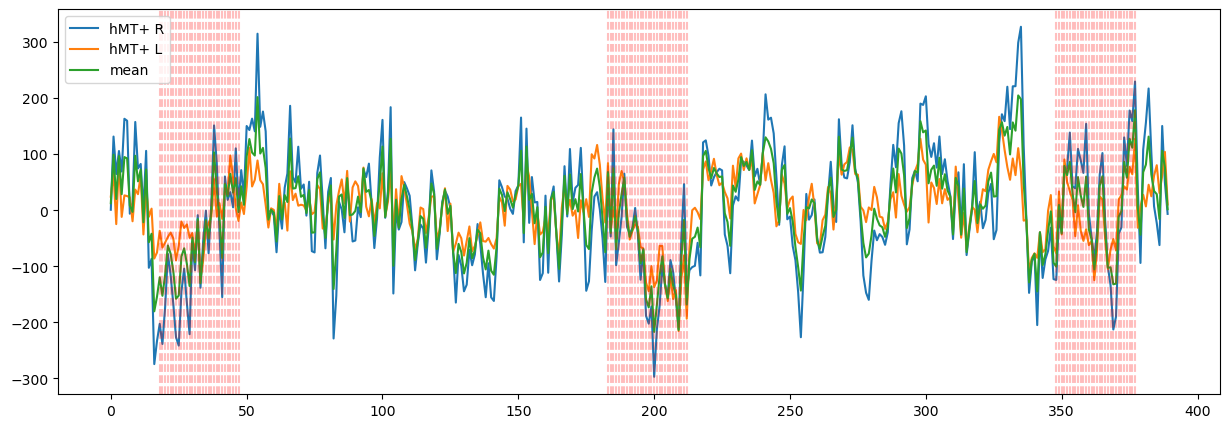

In [172]:
time_series_mean = time_series.mean(axis=1)

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_series)
plt.plot(time_series_mean)
plt.legend([labels[0],labels[1],'mean'])

# highlight the time points of the static events
for i in range(len(static_events_indexes)):
    plt.axvline(x=static_events_indexes[i], color='r', linestyle='--', alpha=0.25)

plt.show()

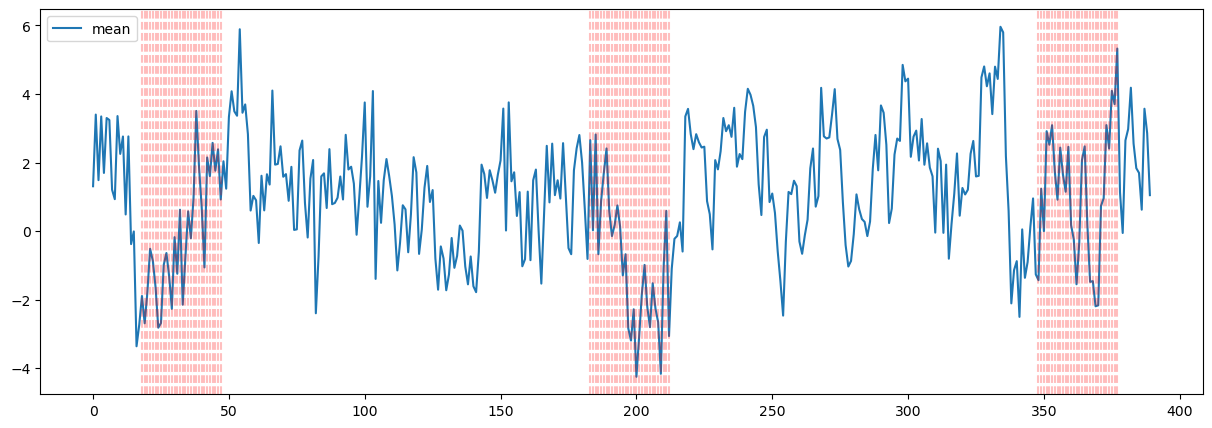

In [173]:
# calculate percent signal change to static events
time_series_mean_static = time_series_mean[static_events_indexes]
time_series_mean_static.mean()

time_series_mean_psc = (time_series_mean - time_series_mean_static.mean()) / abs(time_series_mean_static.mean())

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_series_mean_psc)
plt.legend(['mean'])
# highlight the time points of the static events
for i in range(len(static_events_indexes)):
    plt.axvline(x=static_events_indexes[i], color='r', linestyle='--', alpha=0.25)


Text(0.5, 0, 'Time (volumes)')

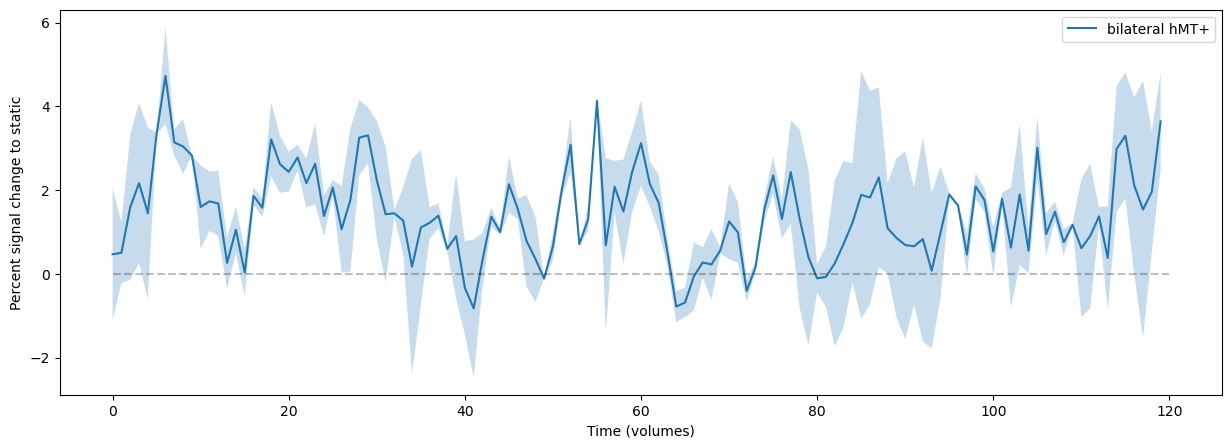

In [174]:
# estimate event related response
time_series_mean_psc_amb = time_series_mean_psc[ambiguous_events_indexes]
time_series_mean_psc_amb_length = time_series_mean_psc_amb.shape[0]//2

# reshape to two columns with half the points each
time_series_mean_psc_amb = time_series_mean_psc_amb.reshape((2,time_series_mean_psc_amb_length)).T

# estimate mean and std
time_series_mean_psc_amb_mean = time_series_mean_psc_amb.mean(axis=1)
time_series_mean_psc_amb_std = time_series_mean_psc_amb.std(axis=1)

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_series_mean_psc_amb_mean)
plt.fill_between(np.arange(time_series_mean_psc_amb_length), time_series_mean_psc_amb_mean-time_series_mean_psc_amb_std, time_series_mean_psc_amb_mean+time_series_mean_psc_amb_std, alpha=0.25)
plt.legend(['bilateral hMT+'])
plt.hlines(0, 0, time_series_mean_psc_amb_length, color='k', linestyle='--', alpha=0.25)
plt.ylabel('Percent signal change to static')
plt.xlabel('Time (volumes)')


(-12.0, 12.0)

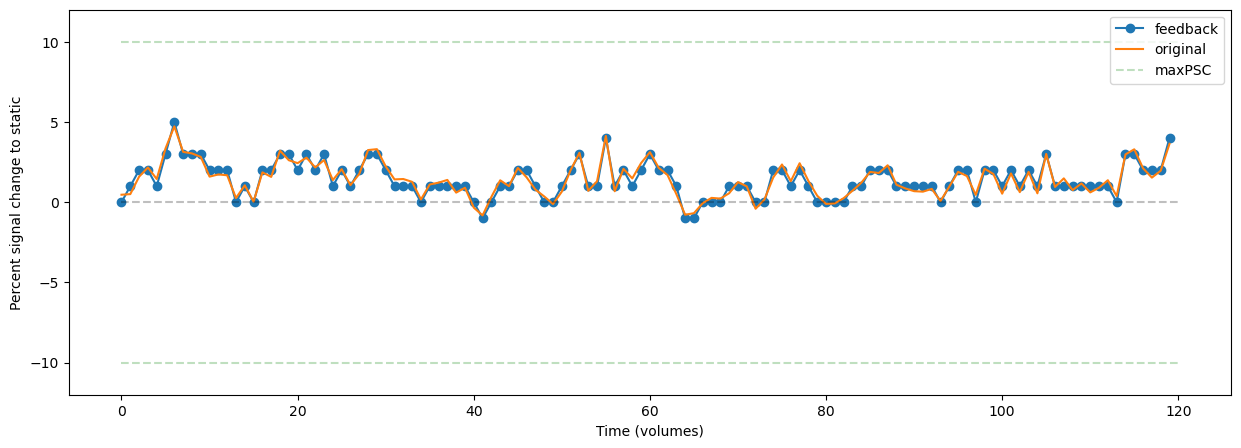

In [175]:
# feedback signal simulation
# remap time_series_mean_psc_amb to a scale between 0 and 10 with step 1. 0 corresponds to psc 0 and 10 corresponds to psc 5. the max value must be 5.
max_psc = 10
time_series_mean_psc_amb_mean_remap = np.round((time_series_mean_psc_amb_mean) * 10 / max_psc)

time_series_mean_psc_amb_mean_remap[time_series_mean_psc_amb_mean_remap>max_psc] = max_psc

# plot them both together
plt.figure(figsize=(15, 5))
plt.plot(time_series_mean_psc_amb_mean_remap, linestyle='solid', marker='o')
plt.plot(time_series_mean_psc_amb_mean)
plt.hlines(max_psc, 0, time_series_mean_psc_amb_length, color='g', linestyle='--', alpha=0.25)
plt.legend(['feedback', 'original', 'maxPSC'])
plt.hlines(-max_psc, 0, time_series_mean_psc_amb_length, color='g', linestyle='--', alpha=0.25)
plt.hlines(0, 0, time_series_mean_psc_amb_length, color='k', linestyle='--', alpha=0.25)
plt.ylabel('Percent signal change to static')
plt.xlabel('Time (volumes)')
plt.ylim((-max_psc-2, max_psc+2))
